# **Tutorial 5 Cross-resolution multi-omics diagonal integration without histology anchor on Human Ovary**

Our data are organized as follows: the `coral_overlap` directory contains the source code of CORAL (available from the source code package we submitted), the `datasets` directory stores the raw datasets, the `inputs` directory contains input data such as the pre-extracted H&E embeddings and filtered cell indices, and the `outputs` directory stores the model outputs.

```
our_model/
│
├── coral_overlap/             # For super-pixel
│   ├── ...                   
│
├── datasets/                  # The datasets
│   ├── ...                   
│
├── inputs/                    # The inputs
│   ├── ...
│
├── outputs/                   # The outputs
│   ├── ... 
```

In [1]:
import os
import sys
import SpaWeaver as sw

import torch
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.multiprocessing as mp

warnings.filterwarnings('ignore')

## 1. Prepare the dataset

### Download the [human ovary](https://spatch.pku-genomics.org/#/dataset/xenium) dataset. Considering the large size of the raw dataset, we provide the related data. These data should be organized into the following directory structure:

```
datasets/
├── SPATCH
│    ├── Xenium/                  # The 1st slice
│    │   ├── OV_RNA_spot.h5ad                    
│    │
│    ├── CODEX/                   # The 2nd slice
│    │   ├── OV_Protein.h5ad
```

For convenience, we provide image embeddings extracted using the H&E foundation model UNI, along with the corresponding cell indices within the sequenced regions. In addition, we provide a gene panel selected based on Moran’s I and coarse-grained cell type annotations derived from marker genes. These data are stored in the `inputs` directory, where each subdirectory contains the following files.

**he_emb**: OV_RNA.npy and OV_Protein.npy

**cell_filter**: OV_RNA.npy and OV_Protein.npy

**panel**: Xenium_OV_markers.npy

**annotations**: OV_annotation.csv

```
inputs/
├── cell_filter/                  # Stores the filtered cell indices
│   ├── OV_RNA.npy                # RNA              
│   ├── OV_Protein.npy            # Protein
│
├── he_emb/                       # Store the extracted H&E image embeddings.
│   ├── OV_RNA.npy                # RNA                 
│   ├── OV_Protein.npy            # Protein
│
├── panel/                        # Store the pre-defined panels.
│   ├── Xenium_OV_markers.npy
│
├── annotations/                  # Store the annotations.
│   ├── OV_annotation.csv
```

**We have uploaded the associated data to Zenodo, which can be accessed through this <a href="https://zenodo.org/records/20428441" style="color:red;">link</a>**.

## 2. Run the model

### 2.1 Define the arguments

In [2]:
sys.argv = [sys.argv[0]]
args = sw.args.build_args()
args.epoch = 2000
args.hops = 0
print(args)

Namespace(seed=0, device=0, optimizer='adam', load_model=False, hops=0, pe_dim=128, hidden_dim=128, n_layers=1, n_heads=2, dropout=0.1, attention_dropout=0.1, activation='elu', epoch=2000, batch_size=4096, loss_fn='mse', lr=0.001, weight_decay=0, sample_name1='Human_Breast_Cancer_Rep1', root_path1='./datasets/Human_Breast_Cancer_Rep1/', sample_name2='Human_Breast_Cancer_Rep2', root_path2='./datasets/Human_Breast_Cancer_Rep2/', save=True, save_tag='fig2', output_folder='./outputs/', image_encoder='uni', img_batch_size=64, num_neighbors=7, scale=0.363788, cell_diameter=-1, resolution=64, mmd_weight=0.01)


The parameters defined above can be adjusted according to your experimental settings.

In [3]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2' # Specify the visible GPUs, as multi-GPU training is utilized in the following code.
world_size = 3 # the number of gpus

args.root_path1 = './datasets/SPATCH/Xenium/'
args.root_path2 = './datasets/SPATCH/CODEX/'

if not os.path.exists("./outputs/"):
    os.makedirs("./outputs/")

if not os.path.exists("./outputs/"):
    os.makedirs("./outputs/")

args.output_folder = './outputs/'
args.save_tag = 'fig6'

if not os.path.exists("./outputs/model/fig6"):
    os.makedirs("./outputs/model/fig6")

if not os.path.exists("./outputs/result/fig6"):
    os.makedirs("./outputs/result/fig6")
    
sw.utils.set_random_seed(args.seed)
print("complete!")

complete!


### 2.2 Panel partitioning

In [4]:
meta_root = './inputs/'
panelA = np.load('./inputs/panel/Xenium_OV_markers.npy')
anno_key = 'annotation'
print("complete!")
panelA.shape

complete!


(1051,)

###  2.3 Gene expression preprocessing

#### 2.3.1 Loading Pseudo Visium data

In [5]:
print("📥 Loading Pseudo Visium data...")
adata1 = sw.pp.read_h5ad('./datasets/SPATCH/Xenium/OV_RNA_spot.h5ad')
adata1 = sw.pp.load_he_emb(adata1, meta_root, 'OV_RNA')
print("complete!")

📥 Loading Pseudo Visium data...
complete!


#### 2.3.2 Loading CODEX data

In [6]:
print("📥 Loading CODEX data...")
adata2 = sw.pp.read_h5ad('./datasets/SPATCH/CODEX/OV_Protein.h5ad')
adata2 = sw.pp.load_he_emb(adata2, meta_root, 'OV_Protein')

anno = pd.read_csv('./inputs/annotations/OV_annotation.csv', index_col=0).loc[adata2.obs_names]
adata2.obs[anno_key] = anno.values.squeeze()

print("complete!")

📥 Loading CODEX data...
complete!


#### 2.3.3 Preprocessing RNA and Protein

In [7]:
print('📊 Data Preprocessing')
adata1 = sw.pp.preprocess_rna(adata1, selected_genes=panelA)
adata2 = sw.pp.preprocess_protein(adata2)
spot_spatial2, agg_mtx2 = sw.utils.generate_hex_spot(adata2.obsm['spatial'], x_interval=27.5, all_in=True)
agg_mtx2_membership = agg_mtx2.tocsr().copy()
agg_mtx2 = sw.pp.normalize_graph(agg_mtx2, norm_type='row')

print("complete!")

📊 Data Preprocessing
complete!


### 2.4 Build graphs, datasets, and models

#### 2.4.1 Building graphs

In [8]:
print("🕸️ Building graphs (KNN)...")
H1 = sw.pp.build_graph(adata1.obsm['spatial'], graph_type='knn', num_neighbors=args.num_neighbors, apply_normalize='both')
H2 = sw.pp.build_graph(adata2.obsm['spatial'], graph_type='knn', num_neighbors=args.num_neighbors, apply_normalize='both')
H1 = sw.utils.sparse_mx_to_torch_sparse_tensor(H1)
H2 = sw.utils.sparse_mx_to_torch_sparse_tensor(H2)
node_HE_fea1, node_HE_fea2 = torch.Tensor(adata1.obsm['he']), torch.Tensor(adata2.obsm['he'])

print("🧩 Aggregating neighborhood features...")
adata1.obsm['sp_he'], adata2.obsm['sp_he'] = sw.utils.re_features(H1, node_HE_fea1, args.hops), sw.utils.re_features(H2, node_HE_fea2, args.hops)

deconv_prefix = 'Abundence_'
domain_names = [col[len(deconv_prefix):] for col in adata1.obs.columns if col.startswith(deconv_prefix)]
codex_domain_names = set(adata2.obs[anno_key].dropna().unique())
if set(domain_names) != codex_domain_names:
    raise ValueError(
        f'Cell types mismatch between spot deconvolution and CODEX annotations: '
        f'{sorted(set(domain_names) ^ codex_domain_names)}'
    )
domain2idx_map = {anno: i for i, anno in enumerate(domain_names)}
anno1 = sw.utils.build_spot_abundance_matrix(adata1, domain_names, prefix=deconv_prefix)
anno2 = adata2.obs[anno_key].map(domain2idx_map).to_numpy()

🕸️ Building graphs (KNN)...
🧩 Aggregating neighborhood features...


#### 2.4.2 Building model

In [9]:
print("🧠 Building model...")

model_1 = sw.model.transformerModel(hops=args.hops,
                           input_dim=args.hidden_dim,
                           n_layers=args.n_layers,
                           num_heads=args.n_heads,
                           hidden_dim=args.hidden_dim,
                           dropout_rate=args.dropout,
                           attention_dropout_rate=args.attention_dropout)

mlp_1 = sw.model.OneLayerMLP(adata1.obsm['sp_he'].shape[-1], args.hidden_dim)
mlp_2 = sw.model.OneLayerMLP(adata2.obsm['sp_he'].shape[-1], args.hidden_dim)
reg_1 = sw.model.OneLayerMLP(args.hidden_dim + 32, adata1.n_vars)
reg_2 = sw.model.OneLayerMLP(args.hidden_dim + 32, adata2.n_vars)
anno_emb = torch.nn.Embedding(len(domain2idx_map), 32)
models = torch.nn.ModuleList([model_1, mlp_1, mlp_2, reg_1, reg_2, anno_emb])

🧠 Building model...


### 2.5 Train the model

Training function with GPU acceleration

In [10]:
print("🚀 Training...")

os.environ['MASTER_ADDR'] = 'localhost'
os.environ['MASTER_PORT'] = str(sw.utils.find_free_port())
mp.spawn(sw.PT.train_Cross_Resolution, args=(world_size, args, adata1, adata2, models, agg_mtx2.tocsr(), anno1, anno2), nprocs=world_size, join=True)

🚀 Training...
Using port: 29500
================================ Train ================================

================================ Train ================================

================================ Train ================================



### 2.6 Test the model

In [11]:
print("🧪 Running inference...")
checkpoint = torch.load(f'{args.output_folder}model/{args.save_tag}/models.pt', map_location='cpu')
model_1.load_state_dict(checkpoint['model_1'])
mlp_1.load_state_dict(checkpoint['mlp_1'])
mlp_2.load_state_dict(checkpoint['mlp_2'])
reg_1.load_state_dict(checkpoint['reg_1'])
reg_2.load_state_dict(checkpoint['reg_2'])
anno_emb.load_state_dict(checkpoint['anno_emb'])

model_1.eval()
mlp_1.eval()
mlp_2.eval()
reg_1.eval()
reg_2.eval()
anno_emb.eval()

he1, he2 = torch.Tensor(adata1.obsm['sp_he']), torch.Tensor(adata2.obsm['sp_he'])
anno1, anno2 = torch.FloatTensor(anno1), torch.LongTensor(anno2)
agg_mtx2_torch = sw.utils.sparse_mx_to_torch_sparse_tensor(agg_mtx2)
pseudo_spot_index2 = [f'pseudo_spot_{i}' for i in range(agg_mtx2.shape[0])]

with torch.no_grad():
    he1_map, he2_map = model_1(mlp_1(he1)), model_1(mlp_2(he2))
    anno1_emb = sw.utils.mean_annotation_embedding(anno1, anno_emb)
    anno2_emb = anno_emb(anno2)
    emb1 = torch.concat([he1_map, anno1_emb], dim=1)
    emb2 = torch.concat([he2_map, anno2_emb], dim=1)

    he2_map_spot = torch.sparse.mm(agg_mtx2_torch, he2_map)
    anno2_onehot = F.one_hot(anno2, num_classes=len(domain2idx_map)).float()
    anno2_abundance_spot = torch.sparse.mm(agg_mtx2_torch, anno2_onehot)
    anno2_emb_spot = sw.utils.mean_annotation_embedding(anno2_abundance_spot, anno_emb)
    emb2_spot = torch.concat([he2_map_spot, anno2_emb_spot], dim=1)

    panelA1 = reg_1(emb1).cpu().numpy()
    panelA2 = reg_1(emb2_spot).cpu().numpy()
    panelB2 = reg_2(emb2).cpu().numpy()
        
if args.save:
    print("💾 Saving outputs...")
    index1, index2 = adata1.obs_names, adata2.obs_names
    panelA, panelB = adata1.var_names, adata2.var_names
    df1 = pd.DataFrame(panelA1, columns=panelA, index=index1)
    df2 = pd.DataFrame(panelA2, columns=panelA, index=pseudo_spot_index2)
    df4 = pd.DataFrame(panelB2, columns=panelB, index=index2)
    df1.to_csv(args.output_folder + 'result/' + args.save_tag + '/A1' + '.csv')
    df2.to_csv(args.output_folder + 'result/' + args.save_tag + '/A2_pseudospot' + '.csv')
    df4.to_csv(args.output_folder + 'result/' + args.save_tag + '/B2' + '.csv')

    pseudo_spot_n_cells = np.asarray(agg_mtx2_membership.sum(axis=1)).reshape(-1).astype(int)
    pseudo_spot_membership = sc.AnnData(
        X=agg_mtx2_membership,
        obs=pd.DataFrame({
            'x': spot_spatial2[:, 0],
            'y': spot_spatial2[:, 1],
            'n_cells': pseudo_spot_n_cells,
        }, index=pseudo_spot_index2),
        var=pd.DataFrame(index=index2),
    )
    pseudo_spot_membership.obsm['spatial'] = spot_spatial2
    pseudo_spot_membership.var['cell_x'] = adata2.obsm['spatial'][:, 0]
    pseudo_spot_membership.var['cell_y'] = adata2.obsm['spatial'][:, 1]
    if anno_key in adata2.obs.columns:
        pseudo_spot_membership.var[anno_key] = adata2.obs[anno_key].astype(str).values
    pseudo_spot_membership.write_h5ad(args.output_folder + 'result/' + args.save_tag + '/A2_pseudospot_membership.h5ad')

    print(f"✅ Outputs saved to {args.output_folder}result/{args.save_tag}/**.")

🧪 Running inference...
💾 Saving outputs...
✅ Outputs saved to ./outputs/result/fig6/**.


### 3. Super-resolution methods, please move to the coral_overlap package to continue

You should first configure the environment according to the official CORAL GitHub repository, and then follow the instructions provided in the README file within the `coral_overlap` directory. 

For convenience, you may also choose to skip this step and directly use the precomputed `Coral_overlap.h5ad` results (already uploaded to Zenodo) for reproduction.

### 4. Visualization

In [53]:
pseudo_spot = pd.read_csv('./outputs/result/fig6/A2_pseudospot.csv', index_col=0)
adata = sc.read_h5ad('./outputs/result/fig6/Coral_overlap.h5ad')
adata_rna = sc.AnnData(np.maximum(adata.obsm['generated_expr_center'], 0))
adata_rna.var_names = list(pseudo_spot.columns)
adata_rna.obsm['spatial'] = adata.obsm['spatial']
adata_rna

AnnData object with n_obs × n_vars = 114649 × 1051
    obsm: 'spatial'

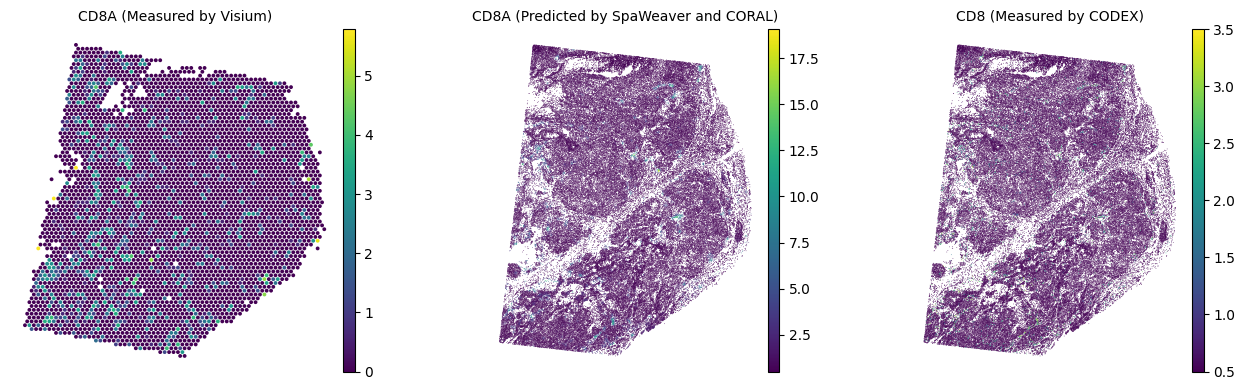

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

sc.pl.embedding(adata1, basis='spatial', color='CD8A', ax=axes[0], show=False)
sc.pl.embedding(adata_rna, basis='spatial', color='CD8A', vmin=0.5, ax=axes[1], show=False)
sc.pl.embedding(adata2, basis='spatial', color='CD8', vmin=0.5, vmax=3.5, ax=axes[2], show=False)

axes[0].set_title('CD8A (Measured by Visium)', fontsize=10)
axes[1].set_title('CD8A (Predicted by SpaWeaver and CORAL)', fontsize=10)
axes[2].set_title('CD8 (Measured by CODEX)', fontsize=10)
axes[0].axis('off')
axes[1].axis('off')
axes[2].axis('off')
axes[0].set_aspect(1)
axes[1].set_aspect(1)
axes[2].set_aspect(1)

plt.tight_layout()
plt.show()

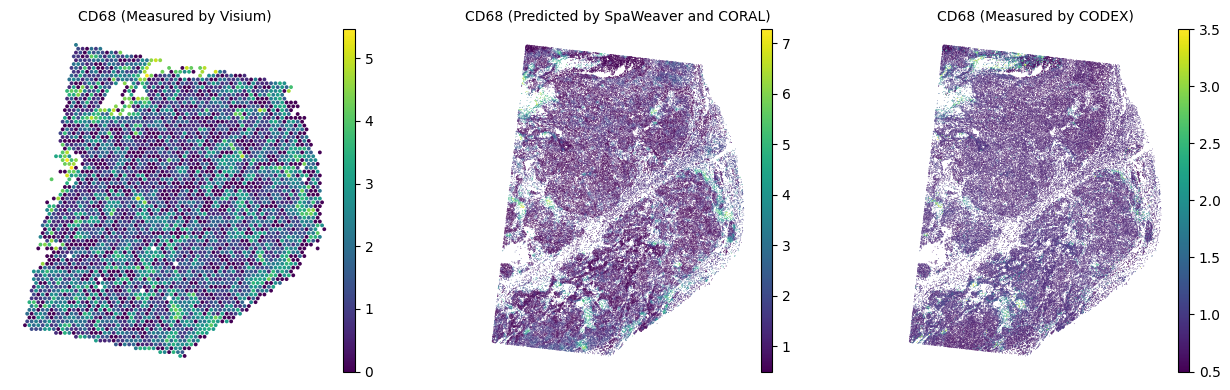

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

sc.pl.embedding(adata1, basis='spatial', color='CD68', ax=axes[0], show=False)
sc.pl.embedding(adata_rna, basis='spatial', color='CD68', vmin=0.5, ax=axes[1], show=False)
sc.pl.embedding(adata2, basis='spatial', color='CD68', vmin=0.5, vmax=3.5, ax=axes[2], show=False)

axes[0].set_title('CD68 (Measured by Visium)', fontsize=10)
axes[1].set_title('CD68 (Predicted by SpaWeaver and CORAL)', fontsize=10)
axes[2].set_title('CD68 (Measured by CODEX)', fontsize=10)
axes[0].axis('off')
axes[1].axis('off')
axes[2].axis('off')
axes[0].set_aspect(1)
axes[1].set_aspect(1)
axes[2].set_aspect(1)

plt.tight_layout()
plt.show()